In [183]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import tqdm

In [184]:
# f =  lambda x,u : np.array([u[1],-1 *np.pow(u[1],2)/(u[0] + 1e-4)])
f =  lambda x,u : np.array([u[1],-0.001 - np.sin(u[0])])

def rk_2(guess,f,degree,h,y_1):
    x = np.arange(np.pi/2, 0, -h)
    np.append(x,0)
    U = np.zeros((len(x),degree))
    U[0] = np.array([y_1,guess])
    for i in range(1,len(x)):
        xi = x[i - 1]
        k1 = f(xi, U[i-1])
        k2 = f(xi + h, U[i-1] + h*k1)
        U[i] = U[i-1] + h*(k1+k2)/2
    return U

In [185]:
guess1 = 0.4
guess2 = 10
h = 0.01
degree = 2
y_0 = 0
y_1 = 1
# f =  lambda x,u : np.array([u[1],-u[0]**2/(x + 1e-4)])
U1 = rk_2(guess1,f,degree,h,y_1)
U2 = rk_2(guess2,f,degree,h,y_1)

In [186]:
epsilon = 1e-12
max_iter = 30000

G1 = U1[-1,0]
G2 = U2[-1,0]

for i in tqdm(range(max_iter)):
    newGuess = guess2 - (G2)*(guess2 - guess1) / (G2 - G1)
    if abs(G2 - G1) < 1e-12:
        print("Division by zero")
        break
    guess1,G1 = guess2,G2
    guess2 = newGuess
    G2 = rk_2(guess2,f,degree,h,y_1)[-1,0]
    if(np.abs(G1) < epsilon):
        print(G1)
        print("converged")
        break


print(guess2)
# rk_2(guess2,f,degree,h,y_1)



  0%|          | 0/30000 [00:00<?, ?it/s]

-7.112366251504909e-17
converged
-0.08847176069888202


[[ 1.00000000e+00 -8.84717607e-02]
 [ 9.99073159e-01 -9.68940788e-02]
 [ 9.98062120e-01 -1.05311154e-01]
 [ 9.96966937e-01 -1.13722522e-01]
 [ 9.95787670e-01 -1.22127716e-01]
 [ 9.94524384e-01 -1.30526268e-01]
 [ 9.93177146e-01 -1.38917707e-01]
 [ 9.91746031e-01 -1.47301560e-01]
 [ 9.90231116e-01 -1.55677353e-01]
 [ 9.88632485e-01 -1.64044606e-01]
 [ 9.86950225e-01 -1.72402839e-01]
 [ 9.85184429e-01 -1.80751568e-01]
 [ 9.83335195e-01 -1.89090307e-01]
 [ 9.81402624e-01 -1.97418564e-01]
 [ 9.79386825e-01 -2.05735848e-01]
 [ 9.77287908e-01 -2.14041660e-01]
 [ 9.75105993e-01 -2.22335502e-01]
 [ 9.72841200e-01 -2.30616868e-01]
 [ 9.70493656e-01 -2.38885251e-01]
 [ 9.68063496e-01 -2.47140138e-01]
 [ 9.65550855e-01 -2.55381015e-01]
 [ 9.62955877e-01 -2.63607361e-01]
 [ 9.60278709e-01 -2.71818652e-01]
 [ 9.57519505e-01 -2.80014359e-01]
 [ 9.54678423e-01 -2.88193950e-01]
 [ 9.51755627e-01 -2.96356885e-01]
 [ 9.48751286e-01 -3.04502624e-01]
 [ 9.45665576e-01 -3.12630619e-01]
 [ 9.42498675e-01 -3

ValueError: x and y must have same first dimension, but have shapes (100,) and (158,)

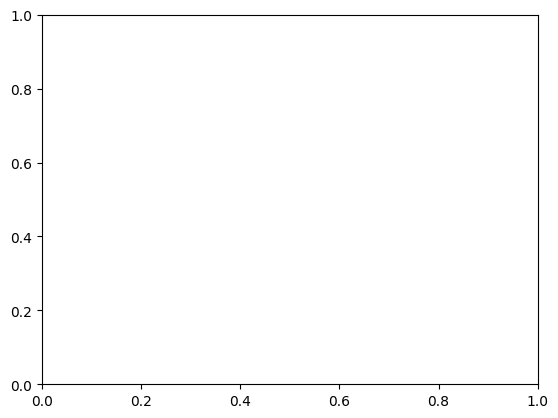

In [187]:
U = rk_2(guess2, f,degree,h,y_1)
print(U)
y = U[:,0]

plt.plot(x[::-1], y[::-1])
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.show()


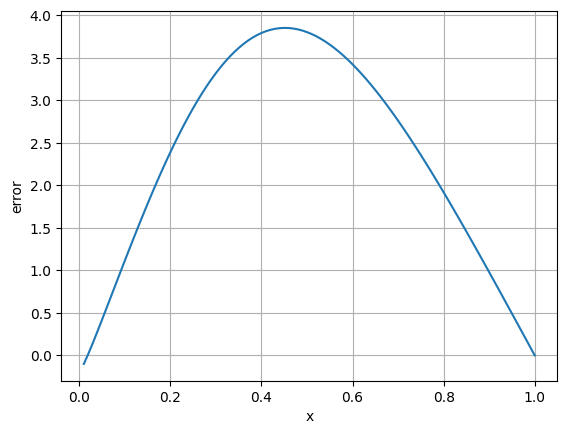

In [ ]:
f_anal = lambda x: 1e-4 * (np.sqrt(100020000*x + 1) - 1)
x = np.arange(1, 0, -h)
np.append(x,0)
error = y - f_anal(x)
plt.plot(x,error)
plt.grid()
plt.xlabel("x")
plt.ylabel("error")
plt.show()

In [ ]:
# import numpy as np

# # Define the system
# def f(x, U):
#     y, v = U
#     dy = v
#     dv = -v**2 / (y + 1e-4)
#     return np.array([dy, dv])

# # RK2 step (midpoint method)
# def rk2_step(x, U, h):
#     k1 = f(x, U)
#     k2 = f(x + h/2, U + h*k1/2)
#     return U + h*k2

# # Integrate backward from x=1 to x=0
# def integrate_backward(s, N=100):
#     h = -1.0 / N          # backward step
#     x = 1.0
#     U = np.array([1.0, s])  # y(1)=1, v(1)=s

#     for _ in range(N):
#         U = rk2_step(x, U, h)
#         x += h

#     return U[0]  # return y(0)

# # Shooting using secant method
# def shooting_rk2(s0, s1, tol=1e-6, max_iter=500):
#     y0 = integrate_backward(s0)
#     y1 = integrate_backward(s1)

#     for _ in range(max_iter):
#         if abs(y1) < tol:
#             return s1

#         s2 = s1 - y1 * (s1 - s0) / (y1 - y0)

#         s0, y0 = s1, y1
#         s1 = s2
#         y1 = integrate_backward(s1)

#     raise RuntimeError("Shooting did not converge")

# # Initial guesses for y'(1)
# s_guess1 = 0.4
# s_guess2 = 5.0

# s_star = shooting_rk2(s_guess1, s_guess2)
# print("Correct initial slope y'(1) =", s_star)


In [ ]:
import numpy as np

# System of first-order ODEs
def f(x, U):
    y, v = U
    dy = v
    dv = -v**2 / (y + 1e-4)
    return np.array([dy, dv])

# One RK4 step
def rk4_step(x, U, h):
    k1 = f(x, U)
    k2 = f(x + h/2, U + h*k1/2)
    k3 = f(x + h/2, U + h*k2/2)
    k4 = f(x + h,   U + h*k3)
    return U + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# Integrate backward from x=1 to x=0
def integrate_backward(s, N=500):
    h = -1.0 / N              # backward step
    x = 1.0
    U = np.array([1.0, s])    # y(1)=1, y'(1)=s

    for _ in range(N):
        U = rk4_step(x, U, h)
        x += h

    return U[0]               # y(0)

# Shooting via secant method
def shooting_rk4(s0, s1, tol=1e-8, max_iter=50):
    y0 = integrate_backward(s0)
    y1 = integrate_backward(s1)

    for _ in range(max_iter):
        if abs(y1) < tol:
            return s1

        s2 = s1 - y1 * (s1 - s0) / (y1 - y0)

        s0, y0 = s1, y1
        s1 = s2
        y1 = integrate_backward(s1)

    raise RuntimeError("Shooting did not converge")

# Initial guesses for y'(1)
s_guess1 = -0.5
s_guess2 = -2.0

s_star = shooting_rk4(s_guess1, s_guess2)
print("Correct initial slope y'(1) =", s_star)


/tmp/ipykernel_112399/997975166.py:7: RuntimeWarning: overflow encountered in scalar power
  dv = -v**2 / (y + 1e-4)
/tmp/ipykernel_112399/997975166.py:16: RuntimeWarning: invalid value encountered in add
  return U + (h/6)*(k1 + 2*k2 + 2*k3 + k4)


RuntimeError: Shooting did not converge